
### **Sign Language Recognition - Deep Learning**


Libraries:

In [240]:


import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import numpy as np
import matplotlib.pyplot as plt

Implementation:

In [153]:
def segmentation(frame, threshold=25):

    global background

    diff = cv2.absdiff(background.astype("uint8"), frame)

    _, processed_frame = cv2.threshold(
        diff,
        threshold,
        255,
        cv2.THRESH_BINARY
    )
    
    contours, _ = cv2.findContours(processed_frame, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return None
    else :
        contours = max(contours, key=cv2.contourArea)

    return (processed_frame, contours)

### Generate Dataset

In [157]:
# =========================
# Camera Initialization
# =========================
cam = cv2.VideoCapture(0, cv2.CAP_V4L2)

# =========================
# ROI (Region of Interest)
# =========================
TOP = 50
BOTTOM = 300
RIGHT = 50
LEFT = 250

# =========================
# Global Variables
# =========================
background = None
count = 0
digit = 0
sample_num = 0


# =========================
# Main Loop
# =========================
while True:

    value, frame = cam.read()

    # Copy frame and flip (mirror effect)
    frame_copy = frame.copy()
    frame_copy = cv2.flip(frame_copy, 1)

    # ROI extraction
    roi = frame_copy[TOP:BOTTOM, RIGHT:LEFT]

    # Preprocessing
    roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    roi_gray = cv2.GaussianBlur(roi_gray, (7, 7), 0)

    # Initialize background
    if background is None:
        background = roi_gray.copy().astype("float")

    # Draw ROI rectangle
    cv2.rectangle(frame_copy, (RIGHT, TOP), (LEFT, BOTTOM), (0, 255, 0), 2)

    

    # Background learning (first 30 frames)
    if count < 30:
        cv2.accumulateWeighted(roi_gray, background, 0.5)
        cv2.putText(frame_copy, "Loading ...", (280, 280), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 255), 2)


    # Hand segmentation
    collection = segmentation(roi_gray)

    if collection is not None:
        roi_processed, contours = collection 
        cv2.drawContours(
                        frame_copy,
                        [contours+(RIGHT, TOP)], # this is for alignment of contours with original frame
                        -1, # draw all contours
                        (0,0,255), 
                        2 
                                    ) 
        cv2.imshow("Processed", roi_processed)
        if k == ord(" "):
            cv2.putText(frame_copy, str(sample_num)+ "Gesture ("+ str(digit)+")", (70, 45), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
            cv2.imwrite("gesture/train/" + str(digit) + "/" + str(digit) +"-" + str(sample_num) + ".jpg", roi_processed)
            sample_num += 1

    # Show camera
    cv2.putText(frame_copy, "Gesture ("+ str(digit)+")", (60, 350), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
    cv2.imshow("Camera", frame_copy)
    count += 1

    # Exit with ESC
    k = cv2.waitKey(1)
    if k == 27:
        break
    
    elif k == 13: # Enter key to save the image
        
        digit = (digit + 1) % 11 
        sample_num = 0
        
        

# =========================
# Release Resources
# =========================
cam.release()
cv2.destroyAllWindows()

In [226]:
train_data_path = "gesture/train"
test_data_path = "gesture/test"

train_data_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(train_data_path,
                                                                                                                                 target_size=(64, 64),
                                                                                                                                 class_mode='categorical',
                                                                                                                                 batch_size=10,
                                                                                                                                 shuffle=True)

test_data_batches = ImageDataGenerator(preprocessing_function=tf.keras.applications.vgg16.preprocess_input).flow_from_directory(test_data_path,
                                                                                                                                 target_size=(64, 64),
                                                                                                                                 class_mode='categorical',
                                                                                                                                 batch_size=10,
                                                                                                                                 shuffle=True)

images_train, labels_train = next(train_data_batches)
print("Train Batch shape:", images_train.shape)
print("Train Labels shape:", labels_train.shape)

images_test, labels_test = next(test_data_batches)
print("Test Batch shape:", images_test.shape)
print("Test Labels shape:", labels_test.shape)

Found 3799 images belonging to 11 classes.
Found 462 images belonging to 11 classes.
Train Batch shape: (10, 64, 64, 3)
Train Labels shape: (10, 11)
Test Batch shape: (10, 64, 64, 3)
Test Labels shape: (10, 11)


In [227]:
def display(images):
    fig, axex = plt.subplots(1, 10, figsize=(30, 20))
    for image, ax in zip(images, axex):
        image = np.clip(image, 0, 1)
        ax.imshow(image)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [228]:
print(train_data_batches.class_indices)

{'00': 0, '01': 1, '02': 2, '03': 3, '04': 4, '05': 5, '06': 6, '07': 7, '08': 8, '09': 9, '10': 10}


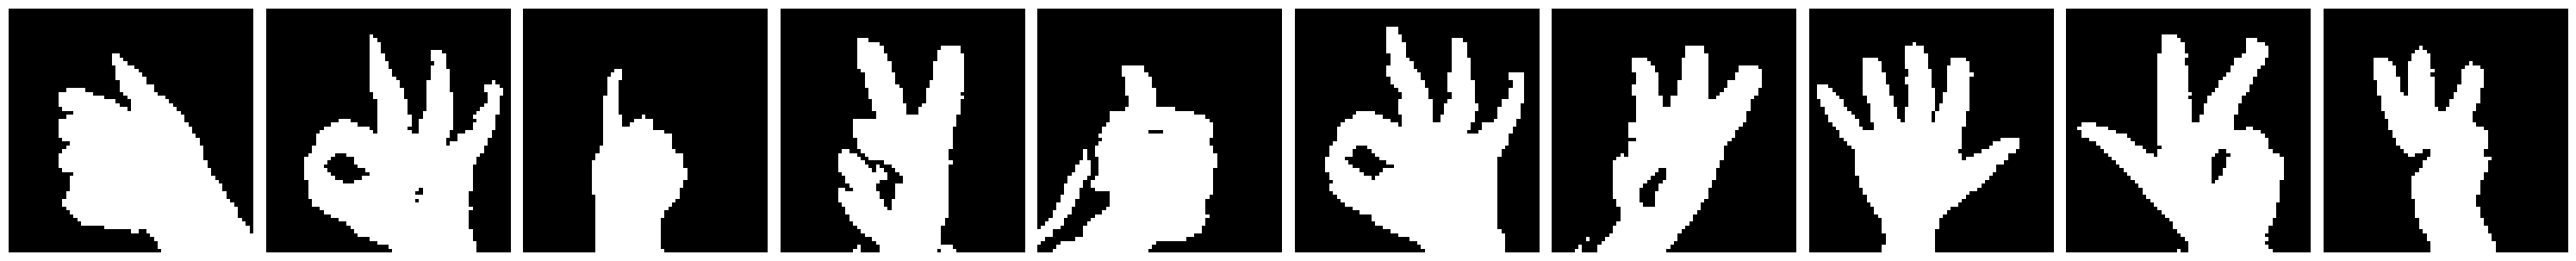

ten
nine
one
two
ten
nine
six
five
three
six


In [229]:
words = {0: "zero", 1: "one", 2: "two", 3: "three", 4: "four", 5: "five", 6: "six", 7: "seven", 8: "eight", 9: "nine", 10: "ten"}



display(images_train)


def digits(labels):
    for label in labels:
        print(words[np.argmax(label)])
    
digits(labels_train)

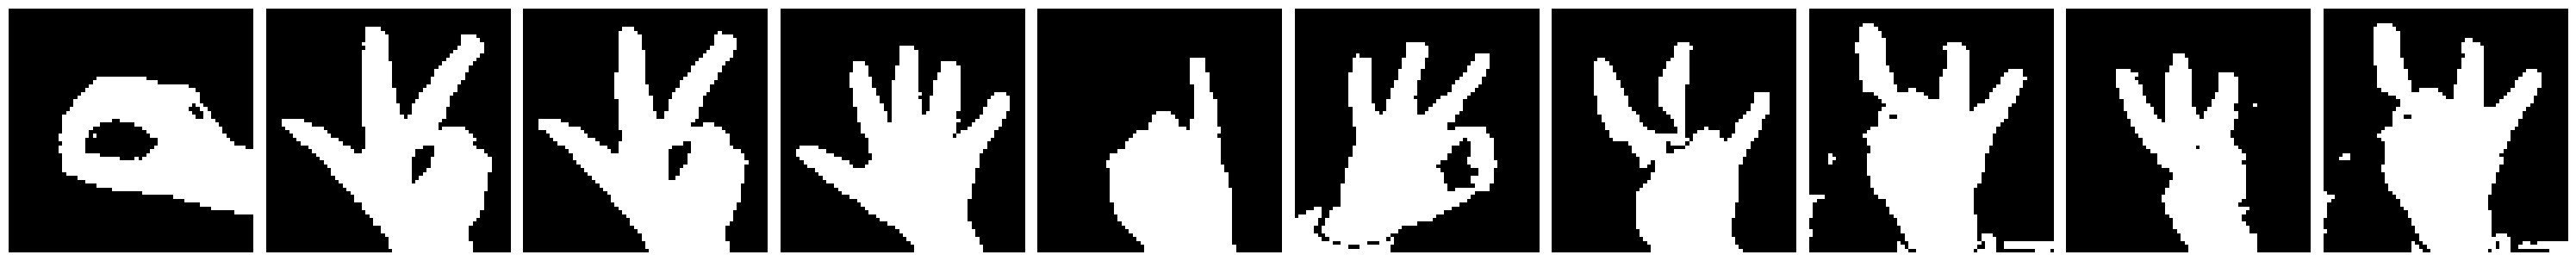

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.]], dtype=float32)

In [230]:
display(images_test)
labels_test

### Create Cnn Model:

In [254]:
# CNN: Convolutional Neural Network

def createModel():
    model = Sequential()
    
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)))
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    
    model.add(Conv2D(128, (3, 3), activation='relu', padding='valid')) 
    model.add(MaxPooling2D(pool_size=(2, 2), strides=2))
    
    model.add(Flatten())
    
    model.add(Dense(64, activation='relu'))
    model.add(Dense(128, activation='relu')) 
    model.add(Dropout(0.2))
    
    model.add(Dense(128, activation='relu'))
    
    model.add(Dense(11, activation='softmax'))
    
    return model
 
model = createModel()
model.summary()

/home/sa7oom/.local/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 31, 31, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │       294,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 11)             │         1,419 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 414,475 (1.58 MB)

 Trainable params: 414,475 (1.58 MB)

 Non-trainable params: 0 (0.00 B)

### Training Cnn Model:

In [255]:

model.compile(optimizer=SGD(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

reduce = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr= 0.0005)
early_stop = EarlyStopping(monitor='val_loss', min_delta=0, patience=3, mode='auto', verbose=1)

In [256]:
model.fit(train_data_batches, epochs=10, callbacks=[reduce, early_stop], validation_data=test_data_batches)

Epoch 1/10
380/380 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.5430 - loss: 1.5325 - val_accuracy: 0.9719 - val_loss: 0.1305 - learning_rate: 0.0010
Epoch 2/10
380/380 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9374 - loss: 0.1842 - val_accuracy: 1.0000 - val_loss: 0.0075 - learning_rate: 0.0010
Epoch 3/10
380/380 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9853 - loss: 0.0476 - val_accuracy: 1.0000 - val_loss: 4.4331e-04 - learning_rate: 0.0010
Epoch 4/10
380/380 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9911 - loss: 0.0305 - val_accuracy: 1.0000 - val_loss: 0.0018 - learning_rate: 0.0010
Epoch 5/10
380/380 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9958 - loss: 0.0139 - val_accuracy: 1.0000 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 6/10
380/380 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9968 - loss: 0.0112 - val_accuracy: 1.0000 - val_loss: 2.9038e-04 - learning_rate: 0.0010
Epoch 7/10
380/380 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9961 - 

### Testing

In [257]:
score = model.evaluate(images_test, labels_test, verbose=0)
score

[6.675711574644083e-07, 1.0]

In [258]:
model.metrics_names

['loss', 'compile_metrics']

In [259]:
print(f"{model.metrics_names[0]}: {score[0]}, {model.metrics_names[1]}: {score[1]*100}")

loss: 6.675711574644083e-07, compile_metrics: 100.0


### Model Save:

In [260]:
model.save("sign_language_model.h5")